In [12]:
import torch
from omegaconf import DictConfig, ListConfig

def look_for_tensors(obj, path="root"):
    """递归搜索对象中所有的张量并打印"""
    found_any = False
    
    if isinstance(obj, torch.Tensor):
        v_sum = obj.abs().sum().item()
        print(f"✅ 找到 Tensor | 路径: {path} | 形状: {obj.shape} | 总和: {v_sum:.4f}")
        return v_sum > 0
    
    if isinstance(obj, dict):
        for k, v in obj.items():
            if look_for_tensors(v, f"{path}['{k}']"): found_any = True
    elif isinstance(obj, (list, tuple, ListConfig)):
        for i, v in enumerate(obj):
            if look_for_tensors(v, f"{path}[{i}]"): found_any = True
            
    return found_any

path = "/data1/wzy/cot-mimic/results/average_cot_vectors/qwen2.5-vl-7b_mathvista_avg_cot_vector_mimic.pt"
# 必须关闭 weights_only 才能读取 DictConfig 等复杂对象
try:
    data = torch.load(path, map_location='cpu', weights_only=False)
    print(f"--- 开始探测文件: {path} ---\n")
    has_data = look_for_tensors(data)
    
    if not has_data:
        print("\n❌ 警告：虽然探测了所有分支，但没发现任何有效数值（全是 0 或 None）。")
except Exception as e:
    print(f"❌ 加载失败: {e}")

--- 开始探测文件: /data1/wzy/cot-mimic/results/average_cot_vectors/qwen2.5-vl-7b_mathvista_avg_cot_vector_mimic.pt ---

✅ 找到 Tensor | 路径: root['ffn_cot_vector'] | 形状: torch.Size([28, 3584]) | 总和: 95776.9062
✅ 找到 Tensor | 路径: root['ffn_hs_vector'] | 形状: torch.Size([28, 3584]) | 总和: 87309.3281
✅ 找到 Tensor | 路径: root['attn_cot_vector'] | 形状: torch.Size([28, 28, 128]) | 总和: 19517.8516


In [12]:
import torch
from omegaconf import DictConfig, ListConfig

def look_for_tensors(obj, path="root"):
    """递归搜索对象中所有的张量并打印"""
    found_any = False
    
    if isinstance(obj, torch.Tensor):
        v_sum = obj.abs().sum().item()
        print(f"✅ 找到 Tensor | 路径: {path} | 形状: {obj.shape} | 总和: {v_sum:.4f}")
        return v_sum > 0
    
    if isinstance(obj, dict):
        for k, v in obj.items():
            if look_for_tensors(v, f"{path}['{k}']"): found_any = True
    elif isinstance(obj, (list, tuple, ListConfig)):
        for i, v in enumerate(obj):
            if look_for_tensors(v, f"{path}[{i}]"): found_any = True
            
    return found_any

path = "/data1/wzy/cot-mimic/results/average_cot_vectors/llama-3.1-8b-instruct_gsm8k_avg_cot_vector_mimic.pt"
# 必须关闭 weights_only 才能读取 DictConfig 等复杂对象
try:
    data = torch.load(path, map_location='cpu', weights_only=False)
    print(f"--- 开始探测文件: {path} ---\n")
    has_data = look_for_tensors(data)
    
    if not has_data:
        print("\n❌ 警告：虽然探测了所有分支，但没发现任何有效数值（全是 0 或 None）。")
except Exception as e:
    print(f"❌ 加载失败: {e}")

--- 开始探测文件: /data1/wzy/cot-mimic/results/average_cot_vectors/llama-3.1-8b-instruct_gsm8k_avg_cot_vector_mimic.pt ---

✅ 找到 Tensor | 路径: root['ffn_cot_vector'] | 形状: torch.Size([32, 4096]) | 总和: 7591.5273
✅ 找到 Tensor | 路径: root['ffn_hs_vector'] | 形状: torch.Size([32, 4096]) | 总和: 8683.3809
✅ 找到 Tensor | 路径: root['attn_cot_vector'] | 形状: torch.Size([32, 32, 128]) | 总和: 5318.5381


Layer 00 Norm: 7.3639
Layer 01 Norm: 7.8447
Layer 02 Norm: 9.8334
Layer 03 Norm: 10.8952
Layer 04 Norm: 16.9467
Layer 05 Norm: 18.0409
Layer 06 Norm: 21.6082
Layer 07 Norm: 26.8753
Layer 08 Norm: 25.1632
Layer 09 Norm: 22.1639
Layer 10 Norm: 23.9886
Layer 11 Norm: 27.2059
Layer 12 Norm: 28.2994
Layer 13 Norm: 26.0357
Layer 14 Norm: 30.3322
Layer 15 Norm: 31.7216
Layer 16 Norm: 30.7543
Layer 17 Norm: 36.5117
Layer 18 Norm: 43.5322
Layer 19 Norm: 51.5223
Layer 20 Norm: 67.7315
Layer 21 Norm: 94.8088
Layer 22 Norm: 107.1356
Layer 23 Norm: 136.3084
Layer 24 Norm: 144.9921
Layer 25 Norm: 195.2434
Layer 26 Norm: 272.5618
Layer 27 Norm: 573.0900


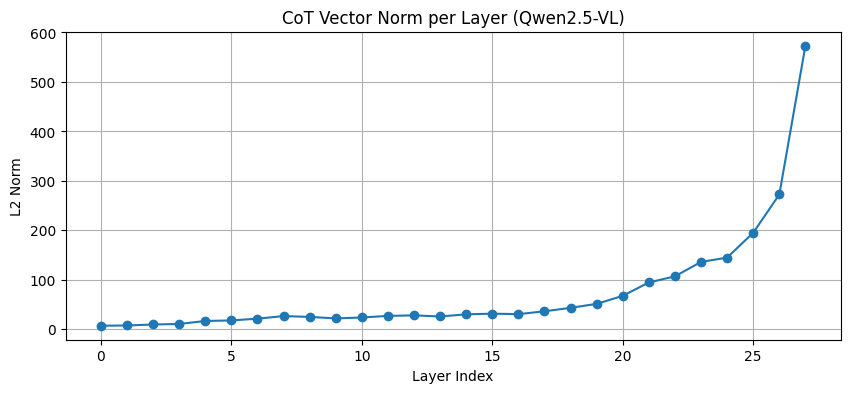

In [13]:
import torch
import matplotlib.pyplot as plt

path = "/data1/wzy/cot-mimic/results/average_cot_vectors/qwen2.5-vl-7b_mathvista_avg_cot_vector_mimic.pt"
data = torch.load(path, map_location='cpu', weights_only=False)

# 提取 FFN 向量
ffn_vec = data['ffn_cot_vector'] # [28, 3584]
norms = torch.norm(ffn_vec, dim=-1)

# 打印数值
for i, n in enumerate(norms):
    print(f"Layer {i:02d} Norm: {n.item():.4f}")

# 画图观察趋势
plt.figure(figsize=(10, 4))
plt.plot(range(len(norms)), norms.numpy(), marker='o')
plt.title("CoT Vector Norm per Layer (Qwen2.5-VL)")
plt.xlabel("Layer Index")
plt.ylabel("L2 Norm")
plt.grid(True)
plt.show()

In [14]:
import torch
from omegaconf import DictConfig, ListConfig

def look_for_tensors(obj, path="root"):
    """递归搜索对象中所有的张量并打印"""
    found_any = False
    
    if isinstance(obj, torch.Tensor):
        v_sum = obj.abs().sum().item()
        print(f"✅ 找到 Tensor | 路径: {path} | 形状: {obj.shape} | 总和: {v_sum:.4f}")
        return v_sum > 0
    
    if isinstance(obj, dict):
        for k, v in obj.items():
            if look_for_tensors(v, f"{path}['{k}']"): found_any = True
    elif isinstance(obj, (list, tuple, ListConfig)):
        for i, v in enumerate(obj):
            if look_for_tensors(v, f"{path}[{i}]"): found_any = True
            
    return found_any

path = "/data1/wzy/cot-mimic/results/average_cot_vectors/qwen2.5-vl-7b_mathvista_avg_cot_vector_mimic.pt"
# 必须关闭 weights_only 才能读取 DictConfig 等复杂对象
try:
    data = torch.load(path, map_location='cpu', weights_only=False)
    print(f"--- 开始探测文件: {path} ---\n")
    has_data = look_for_tensors(data)
    
    if not has_data:
        print("\n❌ 警告：虽然探测了所有分支，但没发现任何有效数值（全是 0 或 None）。")
except Exception as e:
    print(f"❌ 加载失败: {e}")

--- 开始探测文件: /data1/wzy/cot-mimic/results/average_cot_vectors/qwen2.5-vl-7b_mathvista_avg_cot_vector_mimic.pt ---

✅ 找到 Tensor | 路径: root['ffn_cot_vector'] | 形状: torch.Size([28, 3584]) | 总和: 95776.9062
✅ 找到 Tensor | 路径: root['ffn_hs_vector'] | 形状: torch.Size([28, 3584]) | 总和: 87309.3281
✅ 找到 Tensor | 路径: root['attn_cot_vector'] | 形状: torch.Size([28, 28, 128]) | 总和: 19517.8516


In [10]:
import torch

# 加载你刚生成的全量文件
path = "/data1/wzy/cot-mimic/results/average_cot_vectors/qwen2.5-vl-7b_mathvista_avg_cot_vector_mimic.pt"
data = torch.load(path, map_location='cpu', weights_only=False)
vec = data['ffn_cot_vector']

# 看看第 27 层的前 5 个维度的具体数值
print(f"Layer 27 Samples: {vec[27, :5].tolist()}")

Layer 27 Samples: [-0.19138742983341217, 6.572165489196777, -0.44004595279693604, -1.8755292892456055, -2.5283963680267334]


In [17]:
import torch
from omegaconf import DictConfig, ListConfig

def look_for_tensors(obj, path="root"):
    """递归搜索对象中所有的张量并打印"""
    found_any = False
    
    if isinstance(obj, torch.Tensor):
        v_sum = obj.abs().sum().item()
        print(f"✅ 找到 Tensor | 路径: {path} | 形状: {obj.shape} | 总和: {v_sum:.4f}")
        return v_sum > 0
    
    if isinstance(obj, dict):
        for k, v in obj.items():
            if look_for_tensors(v, f"{path}['{k}']"): found_any = True
    elif isinstance(obj, (list, tuple, ListConfig)):
        for i, v in enumerate(obj):
            if look_for_tensors(v, f"{path}[{i}]"): found_any = True
            
    return found_any

path = "/data1/wzy/cot-mimic/results/average_cot_vectors/qwen2.5-vl-7b_mathvista_avg_cot_vector_mimic.pt"
# 必须关闭 weights_only 才能读取 DictConfig 等复杂对象
try:
    data = torch.load(path, map_location='cpu', weights_only=False)
    print(f"--- 开始探测文件: {path} ---\n")
    has_data = look_for_tensors(data)
    
    if not has_data:
        print("\n❌ 警告：虽然探测了所有分支，但没发现任何有效数值（全是 0 或 None）。")
except Exception as e:
    print(f"❌ 加载失败: {e}")

--- 开始探测文件: /data1/wzy/cot-mimic/results/average_cot_vectors/qwen2.5-vl-7b_mathvista_avg_cot_vector_mimic.pt ---

✅ 找到 Tensor | 路径: root['ffn_cot_vector'] | 形状: torch.Size([28, 3584]) | 总和: 95193.3828
✅ 找到 Tensor | 路径: root['ffn_hs_vector'] | 形状: torch.Size([28, 3584]) | 总和: 86991.9062
✅ 找到 Tensor | 路径: root['attn_cot_vector'] | 形状: torch.Size([28, 28, 128]) | 总和: 19214.6445


In [1]:
import json
import os

# 定义你的两个结果文件路径（请根据你实际的 runname 补全路径）
path_1024 = "/data1/wzy/cot-mimic/results/record/icl-qwen2.5-vl-7b-instruct-mathvista-0shot-direct/0shot_1024_baseline.json"
path_4096 = "/data1/wzy/cot-mimic/results/record/icl-qwen2.5-vl-7b-instruct-mathvista-0shot-direct/0shot.json"

def analyze_first_100(file_path):
    if not os.path.exists(file_path):
        print(f"文件未找到: {file_path}")
        return
    
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    # 这里的 records 对应你 eval.py 最后的保存字段
    records = data.get('records', [])
    first_100 = records[:100]
    
    count = len(first_100)
    correct = sum(1 for r in first_100 if r.get('is_correct', False))
    
    print(f"\n📊 文件: {os.path.basename(file_path)}")
    print(f"已处理总数: {len(records)}")
    print(f"前 100 条准确率: {correct}/{count} ({correct/count:.2%})")
    
    # 抽查最后一条的内容，看看长什么样
    if first_100:
        print(f"抽查第 {count} 条 PID: {first_100[-1].get('pid')}")
        print(f"模型预测内容预览: {str(first_100[-1].get('pred'))[:100]}...")

analyze_first_100(path_1024)
analyze_first_100(path_4096)

文件未找到: /data1/wzy/cot-mimic/results/record/icl-qwen2.5-vl-7b-instruct-mathvista-0shot-direct/0shot_1024_baseline.json
文件未找到: /data1/wzy/cot-mimic/results/record/icl-qwen2.5-vl-7b-instruct-mathvista-0shot-direct/0shot.json


In [4]:
from datasets import load_dataset

# 注意这里要把 "json" 改成 "parquet"
dm = load_dataset("parquet", data_files={"train": "/data1/wzy/cot-mimic/mathvista/data/testmini-00000-of-00001-725687bf7a18d64b.parquet"})
ds = load_dataset("parquet", data_files={"train": "/data1/wzy/cot-mimic/mathvista/data/test-00000-of-00002-6b81bd7f7e2065e6.parquet"})
d2=load_dataset("parquet", data_files={"train": "/data1/wzy/cot-mimic/mathvista/data/test-00001-of-00002-6a611c71596db30f.parquet"})

# 打印第一条数据的所有 key
print("数据集包含的字段有:", dm['train'].column_names)
print("数据集包含的字段有:", ds['train'].column_names)
print("数据集包含的字段有:", d2['train'].column_names)


# 打印第一条数据的具体内容，重点看看有没有 'answer'
print("\n样例数据:")
print(dm['train'][0])
print(ds['train'][0])
print(d2['train'][0])

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

数据集包含的字段有: ['pid', 'question', 'image', 'decoded_image', 'choices', 'unit', 'precision', 'answer', 'question_type', 'answer_type', 'metadata', 'query']
数据集包含的字段有: ['pid', 'question', 'image', 'decoded_image', 'choices', 'unit', 'precision', 'answer', 'question_type', 'answer_type', 'metadata', 'query']
数据集包含的字段有: ['pid', 'question', 'image', 'decoded_image', 'choices', 'unit', 'precision', 'answer', 'question_type', 'answer_type', 'metadata', 'query']

样例数据:
{'pid': '1', 'question': "When a spring does work on an object, we cannot find the work by simply multiplying the spring force by the object's displacement. The reason is that there is no one value for the force-it changes. However, we can split the displacement up into an infinite number of tiny parts and then approximate the force in each as being constant. Integration sums the work done in all those parts. Here we use the generic result of the integration.\r\n\r\nIn Figure, a cumin canister of mass $m=0.40 \\mathrm{~kg}$ slides 

In [ ]:
from datasets import load_dataset

# 注意这里要把 "json" 改成 "parquet"
dm = load_dataset("parquet", data_files={"train": "/data1/wzy/cot-mimic/mathvista/data/testmini-00000-of-00001-725687bf7a18d64b.parquet"})
# ds = load_dataset("parquet", data_files={"train": "/data1/wzy/cot-mimic/mathvista/data/test-00000-of-00002-6b81bd7f7e2065e6.parquet"})
# d2=load_dataset("parquet", data_files={"train": "/data1/wzy/cot-mimic/mathvista/data/test-00001-of-00002-6a611c71596db30f.parquet"})

# 打印第一条数据的所有 key
print("数据集包含的字段有:", dm['train'].column_names)
# print("数据集包含的字段有:", ds['train'].column_names)
# print("数据集包含的字段有:", d2['train'].column_names)


# 打印第一条数据的具体内容，重点看看有没有 'answer'
print("\n样例数据:")
print(dm['train'][0])
# print(ds['train'][0])
# print(d2['train'][0])

数据集包含的字段有: ['pid', 'question', 'image', 'decoded_image', 'choices', 'unit', 'precision', 'answer', 'question_type', 'answer_type', 'metadata', 'query']

样例数据:
{'pid': '1', 'question': "When a spring does work on an object, we cannot find the work by simply multiplying the spring force by the object's displacement. The reason is that there is no one value for the force-it changes. However, we can split the displacement up into an infinite number of tiny parts and then approximate the force in each as being constant. Integration sums the work done in all those parts. Here we use the generic result of the integration.\r\n\r\nIn Figure, a cumin canister of mass $m=0.40 \\mathrm{~kg}$ slides across a horizontal frictionless counter with speed $v=0.50 \\mathrm{~m} / \\mathrm{s}$. It then runs into and compresses a spring of spring constant $k=750 \\mathrm{~N} / \\mathrm{m}$. When the canister is momentarily stopped by the spring, by what distance $d$ is the spring compressed?", 'image': 'ima

In [8]:
from datasets import load_dataset
from collections import Counter

# 加载数据
ds = load_dataset("parquet", data_files={"testmini": "/data1/wzy/cot-mimic/mathvista/data/testmini-00000-of-00001-725687bf7a18d64b.parquet"})['testmini']

# 统计任务大类
categories = Counter([item['metadata']['category'] for item in ds])
# 统计所需的技能（注意 skills 是个 list）
skills = Counter([skill for item in ds for skill in item['metadata']['skills']])

print("任务分类分布:", categories)
print("技能需求分布:", skills)
print("q")

任务分类分布: Counter({'math-targeted-vqa': 540, 'general-vqa': 460})
技能需求分布: Counter({'arithmetic reasoning': 353, 'statistical reasoning': 301, 'algebraic reasoning': 281, 'geometry reasoning': 239, 'numeric commonsense': 144, 'scientific reasoning': 122, 'logical reasoning': 37})
q


In [ ]:
import random
from collections import defaultdict
from datasets import load_dataset

def stratified_split(dataset, split_ratio=0.2, seed=42):
    """
    按 category 比例对数据集进行分层切分
    split_ratio: 提取源（Extraction Set）所占比例，默认 0.2 (200条)
    """
    # 1. 按类别对索引进行归类
    category_to_indices = defaultdict(list)
    for idx, item in enumerate(dataset):
        cat = item['metadata']['category']
        category_to_indices[cat].append(idx)
    
    extraction_indices = []
    evaluation_indices = []
    
    random.seed(seed)
    
    # 2. 在每个类别内部进行切分
    for cat, indices in category_to_indices.items():
        random.shuffle(indices)
        split_point = int(len(indices) * split_ratio)
        
        extraction_indices.extend(indices[:split_point])
        evaluation_indices.extend(indices[split_point:])
        
        print(f"类别 [{cat}]: 总计 {len(indices)} 条, 划分到提取集 {split_point} 条")

    # 3. 创建切分后的数据集
    extraction_set = dataset.select(extraction_indices)
    evaluation_set = dataset.select(evaluation_indices)
    
    return extraction_set, evaluation_set

# 加载你的 testmini 数据
ds = load_dataset("parquet", data_files={"testmini": "/data1/wzy/cot-mimic/mathvista/data/testmini-00000-of-00001-725687bf7a18d64b.parquet"})['testmini']
extraction_ds, evaluation_ds = stratified_split(ds)



类别 [math-targeted-vqa]: 总计 540 条, 划分到提取集 108 条
类别 [general-vqa]: 总计 460 条, 划分到提取集 92 条


In [ ]:
import json
import dataset

# 假设你已经得到了 extraction_indices 和 evaluation_indices 列表
split_info = {
    "extraction_pids": [dataset[i]['pid'] for i in extraction_indices],
    "evaluation_pids": [dataset[i]['pid'] for i in evaluation_indices]
}

with open("mathvista_testmini_split.json", "w") as f:
    json.dump(split_info, f, indent=4)

print("切分后的 PID 已保存至 mathvista_testmini_split.json")

In [ ]:
import json
from datasets import load_dataset
from collections import defaultdict
import random

def split_and_save_mathvista(dataset_path, seed=42):
    # 1. 加载原始 testmini
    ds = load_dataset("parquet", data_files={"testmini": dataset_path})['testmini']
    
    # 2. 按类别分层
    category_to_items = defaultdict(list)
    for item in ds:
        cat = item['metadata']['category']
        category_to_items[cat].append(item)
    
    generate_list = []
    evaluate_list = []
    
    random.seed(seed)
    
    # 3. 执行拆分 (20% 提取, 80% 测试)
    for cat, items in category_to_items.items():
        random.shuffle(items)
        split_point = int(len(items) * 0.2)
        
        generate_list.extend(items[:split_point])
        evaluate_list.extend(items[split_point:])
        
        print(f"类别 [{cat}]: 划分 {split_point} 条到 generate_json, {len(items)-split_point} 条到 evaluate_json")

    # 4. 保存为独立的 JSON 文件
    with open("mathvista_generate.json", "w", encoding="utf-8") as f:
        json.dump(generate_list, f, ensure_ascii=False, indent=4)
        
    with open("mathvista_evaluate.json", "w", encoding="utf-8") as f:
        json.dump(evaluate_list, f, ensure_ascii=False, indent=4)
    
    print(f"\n✅ 拆分完成！")
    print(f"📁 提取集文件 (200条): mathvista_generate.json")
    print(f"📁 测试集文件 (800条): mathvista_evaluate.json")

# 替换为你服务器上的真实路径
path = "/data1/wzy/cot-mimic/mathvista/data/testmini-00000-of-00001-725687bf7a18d64b.parquet"
split_and_save_mathvista(path)

In [11]:
import json
import random
from collections import Counter, defaultdict
from datasets import load_dataset

def split_and_verify(dataset_path, seed=42):
    # 1. 加载数据
    ds = load_dataset("parquet", data_files={"testmini": dataset_path})['testmini']
    total_count = len(ds)
    
    # 2. 按 Category 分层
    cat_groups = defaultdict(list)
    for item in ds:
        cat = item['metadata']['category']
        cat_groups[cat].append(item)
    
    gen_set = []
    eval_set = []
    random.seed(seed)
    
    # 3. 执行 2:8 分层切分
    for cat, items in cat_groups.items():
        random.shuffle(items)
        split_idx = int(len(items) * 0.2)
        gen_set.extend(items[:split_idx])
        eval_set.extend(items[split_idx:])

    # 4. 统计分布函数
    def get_dist(data_list):
        cats = Counter([it['metadata']['category'] for it in data_list])
        # skills 是列表，需要展开
        skills = Counter([s for it in data_list for s in it['metadata']['skills']])
        return cats, skills

    gen_cats, gen_skills = get_dist(gen_set)
    eval_cats, eval_skills = get_dist(eval_set)

    # 5. 打印检查报告
    print("="*50)
    print(f"📊 拆分平衡性报告 (种子: {seed})")
    print("-"*50)
    print(f"{'Category':<25} | {'Generate (200)':<15} | {'Evaluate (800)':<15}")
    for cat in cat_groups.keys():
        gen_p = gen_cats[cat] / len(gen_set) * 100
        eval_p = eval_cats[cat] / len(eval_set) * 100
        print(f"{cat:<25} | {gen_p:>6.1f}% ({gen_cats[cat]:>3}题) | {eval_p:>6.1f}% ({eval_cats[cat]:>3}题)")
    
    print("-"*50)
    print(f"{'Top Skills':<25} | {'Generate %':<15} | {'Evaluate %':<15}")
    # 取出现次数最多的前5个技能进行对比
    common_skills = [s for s, _ in Counter([s for it in ds for s in it['metadata']['skills']]).most_common(5)]
    for s in common_skills:
        gen_p = gen_skills[s] / len(gen_set) * 100
        eval_p = eval_skills[s] / len(eval_set) * 100
        print(f"{s:<25} | {gen_p:>6.1f}%          | {eval_p:>6.1f}%")
    print("="*50)

    # 6. 保存文件 (排除无法序列化的图片对象)
    def safe_save(data, filename):
        clean_data = []
        for item in data:
            new_item = {k: v for k, v in item.items() if k != 'decoded_image'}
            clean_data.append(new_item)
        with open(filename, 'w', encoding='utf-8') as f:
            json.dump(clean_data, f, ensure_ascii=False, indent=4)

    safe_save(gen_set, "mathvista_generate.json")
    safe_save(eval_set, "mathvista_evaluate.json")
    print(f"\n✅ 文件已保存：\n1. mathvista_generate.json ({len(gen_set)}条)\n2. mathvista_evaluate.json ({len(eval_set)}条)")

# 执行脚本 (记得替换你的路径)
path = "/data1/wzy/cot-mimic/mathvista/data/testmini-00000-of-00001-725687bf7a18d64b.parquet"
split_and_verify(path)

📊 拆分平衡性报告 (种子: 42)
--------------------------------------------------
Category                  | Generate (200)  | Evaluate (800) 
math-targeted-vqa         |   54.0% (108题) |   54.0% (432题)
general-vqa               |   46.0% ( 92题) |   46.0% (368题)
--------------------------------------------------
Top Skills                | Generate %      | Evaluate %     
arithmetic reasoning      |   39.5%          |   34.2%
statistical reasoning     |   35.5%          |   28.7%
algebraic reasoning       |   24.0%          |   29.1%
geometry reasoning        |   19.0%          |   25.1%
numeric commonsense       |   14.0%          |   14.5%

✅ 文件已保存：
1. mathvista_generate.json (200条)
2. mathvista_evaluate.json (800条)


生成集和测试集，各500条数据

In [6]:
import json
import random
from datasets import load_dataset
from collections import defaultdict

def split_and_fix_mathvista(dataset_path, seed=42):
    print(f"正在重新加载数据并修复字段...")
    ds = load_dataset("parquet", data_files={"testmini": dataset_path})['testmini']
    
    cat_groups = defaultdict(list)
    for item in ds:
        cat = item['metadata']['category']
        cat_groups[cat].append(item)
    
    gen_set, eval_set = [], []
    random.seed(seed)
    
    for cat, items in cat_groups.items():
        random.shuffle(items)
        split_idx = len(items) // 2 
        gen_set.extend(items[:split_idx])
        eval_set.extend(items[split_idx:])

    def strict_save(data, filename):
        cleaned = []
        for it in data:
            # 必须包含所有评测需要的字段
            entry = {
                "question": it.get("question", ""),
                "pid": str(it.get("pid", "")),
                "image": f"images/{it.get('pid')}.jpg",
                "answer": it.get("answer", ""), # 👈 关键：补齐答案
                "choices": it.get("choices", []), # 👈 关键：补齐选项用于归一化
                "question_type": it.get("metadata", {}).get("question_type", "open"),
                "answer_type": it.get("metadata", {}).get("answer_type", "text"),
                "precision": it.get("metadata", {}).get("precision", 0),
                "metadata": it.get("metadata", {})
            }
            cleaned.append(entry)
        with open(filename, 'w', encoding='utf-8') as f:
            json.dump(cleaned, f, ensure_ascii=False, indent=4)

    strict_save(gen_set, "mathvista_generate_500.json")
    strict_save(eval_set, "mathvista_evaluate_500.json")
    print(f"✅ 修复完成！请确认文件已包含 'answer' 和 'choices' 字段。")

path = "/data1/wzy/cot-mimic/mathvista/data/testmini-00000-of-00001-725687bf7a18d64b.parquet"
split_and_fix_mathvista(path)

正在重新加载数据并修复字段...
✅ 修复完成！请确认文件已包含 'answer' 和 'choices' 字段。
